In [2]:
#Feature Engineering
import pandas as pd
train=pd.read_csv('data/타이타닉/train.csv')
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
#각 칼럼의 상관관계를 비교해주는 함수(corr)
before_corr=train.corr(numeric_only=True)
before_corr

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
PassengerId,1.000000,-0.005007,-0.035144,0.036847,-0.057527,-0.001652,0.012658
Survived,-0.005007,1.000000,-0.338481,-0.077221,-0.035322,0.081629,0.257307
Pclass,-0.035144,-0.338481,1.000000,-0.369226,0.083081,0.018443,-0.549500
Age,0.036847,-0.077221,-0.369226,1.000000,-0.308247,-0.189119,0.096067
SibSp,-0.057527,-0.035322,0.083081,-0.308247,1.000000,0.414838,0.159651
Parch,-0.001652,0.081629,0.018443,-0.189119,0.414838,1.000000,0.216225
Fare,0.012658,0.257307,-0.549500,0.096067,0.159651,0.216225,1.000000


In [4]:
#table에 각 열의 Nan값들의 합을 구해줌(.isnull().sum())
train.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [5]:
test=pd.read_csv('data/타이타닉/test.csv')
test.head()

#train과 test값을 리스트화하여 출력함(둘 다 한꺼번에 출력하는 방법임)(data_list)
data_list=[train, test]
data_list[0].head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [6]:
#1. 성별 ▶ 코드로 변경(데이터 리스트에서 데이터를 꺼냄) __ 피처 엔지니어링 작업(input data를 output에 적당한 type으로 변경해주는 작업)
for data in data_list: #data_list에서 data를 꺼냄
    #Sex의 데이터값을 카테고리를 분류해서 코드를 부여하겠음을 의미
    data['Sex'] = data['Sex'].astype('category').cat.codes
#기존 male female에서 0,1로 분류됨(外 여러개 카테고리면 0,1,2,3... 식으로 구분됨)
train['Sex'].head(5)



0    1
1    0
2    0
3    0
4    1
Name: Sex, dtype: int8

In [7]:
#나이
train['Age'].isnull().sum() #Nul값 177개 확인 
#1. 성별 평균 구하기(groupby)
gender_mean=train.groupby('Sex')['Age'].mean()
gender_mean # 男: 30.7세 女:27.9세

#2. 남자/여자이면서 Null 인 경우 각 성별 평균값에 넣어주기
for data in data_list:
    #filt값이 성이 여자/남자고, 나이가 Null인 경우(filt값) → 각 성별 평균값에 넣어줌
    filt=(data['Sex']==0) & (data['Age'].isnull())
    data.loc[filt, "Age"]=gender_mean[1]
    filt=(data['Sex']==1) & (data['Age'].isnull())
    data.loc[filt, "Age"]=gender_mean[1]

In [8]:
# Age 데이터를 5개의 범주으로 나누기(pd.cut) 새로 AgeRange 열 지정
train['AgeRange']=pd.cut(train['Age'],5)
train['AgeRange'].value_counts() #전체 나이를 5개로 나누어 각 총 인원을 출력

AgeRange
(16.336, 32.252]    523
(32.252, 48.168]    188
(0.34, 16.336]      100
(48.168, 64.084]     69
(64.084, 80.0]       11
Name: count, dtype: int64

In [9]:
#나이를 5개의 범주로 나눔
for data in data_list:
    #나이가 16세 이하인 경우에는 Age2열에 0으로 넣어줌
    filt=data['Age']<=16
    data.loc[filt,'Age2']=0
    #나이가 16세 이상 32세 이하인 경우에는 Age2열에 1으로 넣어줌
    filt=(data['Age']>16) & (data['Age']<=32) ##data마다 () 넣어줘야함
    data.loc[filt,'Age2']=1
    #나이가 32세 이상 48세 이하인 경우에는 Age2열에 1으로 넣어줌
    filt=(data['Age']>32)  & (data['Age']<=48) ##data마다 () 넣어줘야함
    data.loc[filt,'Age2']=2
    #   나이가 48세 이상 64세 이하인 경우에는 Age2열에 1으로 넣어줌
    filt=(data['Age']>48)  & (data['Age']<=64) ##data마다 () 넣어줘야함
    data.loc[filt,'Age2']=3
    #나이가 64세 이상경우에는 Age2열에 1으로 넣어줌
    filt=data['Age']>64 
    data.loc[filt,'Age2']=4

#Age2열에 나이대별(0~4)로 사람 수의 총합을 출력
data['Age2'].value_counts()



Age2
1.0    264
2.0     81
3.0     37
0.0     34
4.0      2
Name: count, dtype: int64

In [10]:
#AgeRange가 train열에 있으면, 삭제한다(if를 사용함으로 없을 경우 발생할 수 있는 오류를 방지)
if 'AgeRange' in train.columns:
    train.drop(columns='AgeRange', inplace=True)

train.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked', 'Age2'],
      dtype='object')

In [11]:
# 데이터 덮어주기(Age2 데이터를 Age에 넣고 Age열 제거하기)
for data in data_list:
    if 'Age2' in data.columns: # Age2가 data columns에 있다면?
        data['Age']=data['Age2'] #덮어쓰기
        data.drop(columns='Age2',inplace=True) #Age2 Columns 제거

train['Age'].value_counts() # 이전 Age2 자료가 Age로 이동하였음을 알 수 있음

Age
1.0    523
2.0    188
0.0    100
3.0     69
4.0     11
Name: count, dtype: int64

In [12]:
#Name(점 앞 글자만 출력), 이름에서 호칭(Mr. Mrs....)를 뽑아서 코드로 전환
train['Name'].head(5)
#내역을 추출하는 함수(정규식)
train['Title']=train['Name'].str.extract(' ([A-Za-z]+)\\.')
titles=train['Title'].value_counts()
titles.index 

#호칭을 하나씩 꺼내와서
 ##1. 대표적 4개 제외 나머지는 others에 넣음
others=[i for i in titles.index if i not in ['Mr','Mrs','Miss','Master']]
print(others)

# title 값을 변경(title의 others 값들은 title 내 Other이라는 새로운 항목에 넣어줌)
train['Title']=train['Title'].replace(others,'Other')
train['Title'].value_counts()

# 데이터 타입을 변경하기(str → code) # 알파벳 순서로 코드번호가 형성됨
train['Title_name']=train['Title'].astype('category').cat.codes
train[['Title', 'Title_name']].value_counts()

['Dr', 'Rev', 'Col', 'Mlle', 'Major', 'Ms', 'Mme', 'Don', 'Lady', 'Sir', 'Capt', 'Countess', 'Jonkheer']


Title   Title_name
Mr      2             517
Miss    1             182
Mrs     3             125
Master  0              40
Other   4              27
Name: count, dtype: int64

In [13]:
for data in data_list:
    data['Title']=data['Name'].str.extract(' ([A-Za-z]+)\\.')
    titles=data['Title'].value_counts()
    others=[i for i in titles.index if i not in ['Mr','Mrs','Miss','Master']]
    data['Title']=data['Title'].replace(others,"Other")
    data['Title_name']=data['Title'].astype('category').cat.codes


test[['Title', 'Title_name']].value_counts()

#필요없는 Columns 제거하기(Name, title 제거)
train.columns

for data in data_list:
    if "Name" in data.columns:
        data.drop(columns="Name",inplace=True)
    if 'Title' in data. columns:
        data.drop(columns='Title',inplace=True)


In [14]:
#배우자/형제자매/부모/자식수 + 1(FamilySize를 만들기 위해 형제자매/가족을 더한 후 이후에 SibSp, Parch를 제거)하고 FamilySize라는 새로운 열 만들기
for data in data_list:
    data['FamilySize']=data['SibSp'] + data['Parch'] +1

train['FamilySize'].value_counts()

#필요없어진 열데이터 제거하기(Sibp, Parch 제거)
for data in data_list:
    if 'Sibp' in data.columns:
        data.drop(columns='Sibsp', inplace=True)
    if 'Parcb' in data.columns:
        data.drop(columns='Parch',inplace=True)

train.columns #결과확인


Index(['PassengerId', 'Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch',
       'Ticket', 'Fare', 'Cabin', 'Embarked', 'Title_name', 'FamilySize'],
      dtype='object')

In [15]:
# 항구 S C Q중 Null 값은 S항구에 포함시켜주고 각각 코드로 전환시켜주기(0,1,2)(cf) 2개의 경우는 .astype('category').cat.codes로 가능

#1. 가장 많은 항구를 구하기
train['Embarked'].value_counts() # S항구 가장 多

#2. null값을 S값으로 변환시켜줌
for data in data_list:
    data.fillna({'Embarked':'S'},inplace=True)

train['Embarked'].value_counts() # S항구 가장 多


#3. 각 항구별 S,C,Q 항을 코드로 변환시켜주기
for data in data_list:
    for idx in range(len(data)):
        if data.loc[idx,'Embarked']=='S':
            data.loc[idx,'Embarked']=0
        elif data.loc[idx,'Embarked']=='C':
            data.loc[idx,'Embarked']=1
        elif data.loc[idx,'Embarked']=='Q':
            data.loc[idx, 'Embarked']=2
    # if isinstance(data['Embarked'],str):
    data['Embarked']=data['Embarked'].apply(lambda x: int(x) if not isinstance(x, int) else x) # Embarked의 값이 str값이면, int값으로 변환하기
        # data['Embarked']=data['Embarked'].apply(lambda x: int(x) if not isinstance(x, int)else x) # Embarked의 값이 str값이면, int값으로 변환하기

train['Embarked'].value_counts()



Embarked
0    646
1    168
2     77
Name: count, dtype: int64

In [16]:
train.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch',
       'Ticket', 'Fare', 'Cabin', 'Embarked', 'Title_name', 'FamilySize'],
      dtype='object')

In [17]:
# 객실(Cabin) 앞자리 1자리를 변환하기

#1. 자료확인
train['Cabin'].value_counts() #객실넘버 확인 가능

#2.객실번호 앞 글자 출력하기
for data in data_list:
    #Cabin의 Null값을 N으로 변환하기 + 코드값으로 변환하기
    #방법1: data['Cabin']=data['Cabin'].fillna('N')
    data.fillna({'Cabin':'N'},inplace=True)
    data['Cabin']=data['Cabin'].apply(lambda x : x[0]) ##
    data["Cabin"]=data['Cabin'].astype('category').cat.codes

data['Cabin'].isnull().sum()
# #cf. str 출력구조
# str="ABCD"
# str[0]

np.int64(0)

In [18]:
# fare(요금)을 4개의 구간으로 나눠서 코드로 출력하기

#1. Fare을 4개의 구간으로 나누기
train['FareeRange']=pd.cut(train['Fare'],4)

#2. Fare의 요금을 4개의 구간을 Fare2에 넣음
for data in data_list:
    filt=data['Fare']<=128
    data.loc[filt,'Fare2']=0
    filt=(data['Fare']>128) & (data['Fare']<=256)
    data.loc[filt,'Fare2']=1
    filt=(data['Fare']>256) & (data['Fare']<=384)
    data.loc[filt,'Fare2']=2
    filt=(data['Fare']>384)
    data.loc[filt,'Fare2']=3

train['Fare2'].value_counts() #결과확인(0 854, 1 29, 2 6, 3 3)

#3 Fare2값을 Fare에 덮어넣기
for data in data_list:
    if 'Fare2' in data.columns:
        data['Fare']=data['Fare2']
        data.drop(columns='Fare2',inplace=True)
    if 'FareeRange' in data.columns:
        data.drop(columns='FareeRange',inplace=True)

    data.fillna({"Fare":0}, inplace=True)


In [19]:
drop_list=['PassengerId',"Ticket","Cabin"]
for data in data_list:
    for col in drop_list:
        if col in data.columns:
            data.drop(columns=col,inplace=True)

train.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Title_name,FamilySize
0,0,3,1,1.0,1,0,0.0,0,2,2
1,1,1,0,2.0,1,0,0.0,1,3,2
2,1,3,0,1.0,0,0,0.0,0,1,1
3,1,1,0,2.0,1,0,0.0,0,3,2
4,0,3,1,2.0,0,0,0.0,0,2,1


In [20]:
#저장하기
train.to_csv('data/타이타닉/훈련.csv',index=False)
test.to_csv('data/타이타닉/테스트.csv',index=False)


#train 상관관계 다시 확인하기- Sex, title_name, FamilySize 추가
train.corr(numeric_only=True)
train

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Title_name,FamilySize
0,0,3,1,1.0,1,0,0.0,0,2,2
1,1,1,0,2.0,1,0,0.0,1,3,2
2,1,3,0,1.0,0,0,0.0,0,1,1
3,1,1,0,2.0,1,0,0.0,0,3,2
4,0,3,1,2.0,0,0,0.0,0,2,1
...,...,...,...,...,...,...,...,...,...,...
886,0,2,1,1.0,0,0,0.0,0,4,1
887,1,1,0,1.0,0,0,0.0,0,1,1
888,0,3,0,1.0,1,2,0.0,0,1,4
889,1,1,1,1.0,0,0,0.0,1,2,1


In [21]:
train=pd.read_csv('data/타이타닉/훈련.csv')
test=pd.read_csv('data/타이타닉/테스트.csv')
train.corr(numeric_only=True)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Title_name,FamilySize
Survived,1.000000,-0.338481,-0.543351,-0.043800,-0.035322,0.081629,0.147466,0.106811,-0.052471,0.016639
Pclass,-0.338481,1.000000,0.131900,-0.358769,0.083081,0.018443,-0.298580,0.045702,-0.195910,0.065997
Sex,-0.543351,0.131900,1.000000,0.070220,-0.114631,-0.245489,-0.114771,-0.116569,0.040484,-0.200988
Age,-0.043800,-0.358769,0.070220,1.000000,-0.218747,-0.135227,0.063220,-0.051334,0.427999,-0.217063
SibSp,-0.035322,0.083081,-0.114631,-0.218747,1.000000,0.414838,0.040996,-0.059961,-0.213887,0.890712
Parch,0.081629,0.018443,-0.245489,-0.135227,0.414838,1.000000,0.141616,-0.078665,-0.122792,0.783111
Fare,0.147466,-0.298580,-0.114771,0.063220,0.040996,0.141616,1.000000,0.047596,-0.044644,0.098769
Embarked,0.106811,0.045702,-0.116569,-0.051334,-0.059961,-0.078665,0.047596,1.000000,-0.081928,-0.080281
Title_name,-0.052471,-0.195910,0.040484,0.427999,-0.213887,-0.122792,-0.044644,-0.081928,1.000000,-0.207530
FamilySize,0.016639,0.065997,-0.200988,-0.217063,0.890712,0.783111,0.098769,-0.080281,-0.207530,1.000000


In [22]:
#아래 자료를 바탕으로 학습하기
from sklearn.neighbors import KNeighborsClassifier
model=KNeighborsClassifier()

X_train=train.iloc[:,1:].values
y_train=train.iloc[:,0].values
# X.shape, y.shape
model=KNeighborsClassifier()
model.fit(X_train,y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [23]:
y_train_pred=model.predict(X_train)
X_test=test.iloc[:,:].values
y_test_pred=model.predict(X_test)

In [24]:
test['Prediction']=y_test_pred
y_test_pred=model.predict(X_test)

In [25]:
df_test=pd.read_csv('data/타이타닉/test.csv')
df_test['Prediction']=y_test_pred
df_test.head()


,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Prediction
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q,0
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S,1
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q,0
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S,0
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S,0


In [26]:
#예측하기
y_pred=model.predict(X_train)
y_pred

#train에 새로 Prediction을 넣고 y_pred 결과를 대입해줌 
train['Prediction']=y_pred



In [27]:
#Survived 와 Prediction 값과 동일한 것 찾기
filt=train['Survived'] == train['Prediction']
right=train[filt]
train.shape, right.shape, right.shape[0]/train.shape[0] #실제값과 예측값 맞춘 수


((891, 11), (755, 11), 0.8473625140291807)

In [28]:
y_train_pred=model.predict(X_train)

In [29]:
submission=pd.read_csv('data/타이타닉/gender_submission.csv')
submission['Prediction']=y_test_pred
submission.to_csv('data/타이타닉/gender_submission.csv',index=False)

In [30]:
import pandas as pd
df=pd.read_csv('data/타이타닉/test.csv')
cols=['Name','Sex','Age','Fare','Pclass','Embarked']
df=df[cols]
df.columns=['이름','성별','나이','요금','등급','항구']
df.columns

Index(['이름', '성별', '나이', '요금', '등급', '항구'], dtype='object')

In [31]:
test=pd.read_csv('data/타이타닉/테스트.csv')
train=pd.read_csv('data/타이타닉/훈련.csv')
#학습모델로 학습시키기
from sklearn.neighbors import KNeighborsClassifier
model=KNeighborsClassifier()
X=train.iloc[:,1:].values
y=train.iloc[:,0].values

#학습모델만들기
model.fit(X,y)
X_pred=test.iloc[:,:].values
y_pred=model.predict(X_pred)

df_test=pd.read_csv('data/타이타닉/test.csv')
df_test['pred']=y_pred
df_test.head(5)


,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,pred
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q,0
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S,1
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q,0
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S,0
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S,0


In [32]:
train=pd.read_csv('data/타이타닉/훈련.csv')
train['Age'].value_counts()
train.head(3)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Title_name,FamilySize
0,0,3,1,1.0,1,0,0.0,0,2,2
1,1,1,0,2.0,1,0,0.0,1,3,2
2,1,3,0,1.0,0,0,0.0,0,1,1


In [33]:
import matplotlib.pyplot as plt
import seaborn as sns # 간단하게 막대그래프를 출력해주는 라이브러리
# plt.figure(figsize=(10, 3))
# sns.countplot(x='Age', hue='Survived',data=train, palette='Set2')

plt.figure(figsize=(10,3))
def rate(col):
    group=train[col].value_counts()
    df_total=group.to_frame('전체')
    group=train[train['Survived']==1][col].value_counts()
    df_survived=group.to_frame('생존')
    df_survived
    join=df_total.join(df_survived)
    join['사망']=join['전체']-join['생존']
    join['생존률']=join['생존']/join['전체']*100
    join['생존률']=round(join['생존률'],2)
    return join

<Figure size 1000x300 with 0 Axes>

In [34]:

df=rate("Pclass")
df

,전체,생존,사망,생존률
Pclass,,,,
3,491,119,372,24.24
1,216,136,80,62.96
2,184,87,97,47.28


In [35]:
#index값 변경
df_train=pd.read_csv('data/타이타닉/train.csv')
df_train['AgeRange']=pd.cut(df_train['Age'],5)
range=df_train['AgeRange'].value_counts()
#시리즈로 변경해주는 함수
range=pd.Series(range)
ranges=range.sort_index().index
index=[]
for range in ranges:
    range=str(range).replace('(','').replace(']','').split(',') #range를 str로 변경 후 replace로 소/대괄호 제거 후 ,로 구분기호 생성 시 → 배열생성
    range=f'{float(range[0]):.0f}~{float(range[1]):.0f}'
    index.append(range)
index

df=rate('Age')
df=df.sort_index()
df.index=index
df


,전체,생존,사망,생존률
0~16,100,55,45,55.00
16~32,523,180,343,34.42
32~48,188,76,112,40.43
48~64,69,30,39,43.48
64~80,11,1,10,9.09


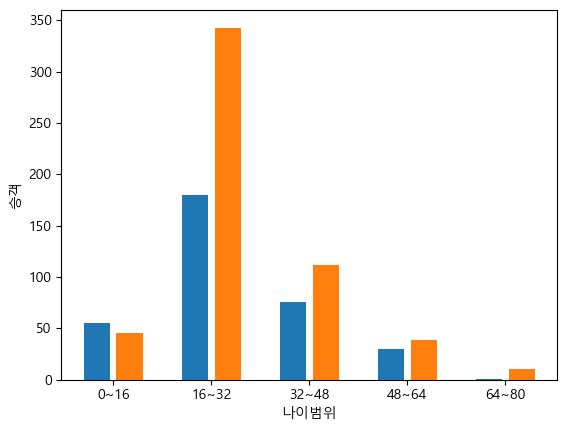

In [37]:
import numpy as np
plt.rc('font',family="Malgun Gothic")
index=np.arange(len(df))*3
plt.bar(index+0,df['생존'])
plt.bar(index+1,df['사망'])
plt.xticks([x+0.5 for x in index],df.index)
plt.xlabel('나이범위')
plt.ylabel('승객')
plt.show()